# Use Logistic Regression to Predict Market Movement : Up/Down Based on Past Returns: Use Training and Test Data

In [32]:
### Reference https://github.com/Mashimo/datascience/blob/master/01-Regression/LogisticRegressionSM.ipynb

import pandas as pd
import csv


import numpy as np  
import matplotlib.pyplot as plt  
import seaborn as seabornInstance 
import statsmodels.api as sm

import statsmodels.formula.api as smf


from sklearn.model_selection import train_test_split 
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
from sklearn import metrics

In [33]:
#read Default data
Smarket = pd.read_csv('H:\My Documents\TEACHING\Financial_Data_Analytics\MS_FINANCE_REVISED\DATA\Smarket.csv')

In [34]:
Smarket.head()

,Unnamed: 0,Year,Lag1,Lag2,Lag3,Lag4,Lag5,Volume,Today,Direction
0,1,2001,0.381,-0.192,-2.624,-1.055,5.010,1.1913,0.959,Up
1,2,2001,0.959,0.381,-0.192,-2.624,-1.055,1.2965,1.032,Up
2,3,2001,1.032,0.959,0.381,-0.192,-2.624,1.4112,-0.623,Down
3,4,2001,-0.623,1.032,0.959,0.381,-0.192,1.2760,0.614,Up
4,5,2001,0.614,-0.623,1.032,0.959,0.381,1.2057,0.213,Up


In [35]:
#Droppong column 0 as it is not needed and storing the data in a new object d2
m2=Smarket.drop(Smarket.columns[0], axis=1)
m2.head()

,Year,Lag1,Lag2,Lag3,Lag4,Lag5,Volume,Today,Direction
0,2001,0.381,-0.192,-2.624,-1.055,5.010,1.1913,0.959,Up
1,2001,0.959,0.381,-0.192,-2.624,-1.055,1.2965,1.032,Up
2,2001,1.032,0.959,0.381,-0.192,-2.624,1.4112,-0.623,Down
3,2001,-0.623,1.032,0.959,0.381,-0.192,1.2760,0.614,Up
4,2001,0.614,-0.623,1.032,0.959,0.381,1.2057,0.213,Up


In [36]:
#provide the summary stat of the quantitative variables
m2.describe()

,Year,Lag1,Lag2,Lag3,Lag4,Lag5,Volume,Today
count,1250.000000,1250.000000,1250.000000,1250.000000,1250.000000,1250.00000,1250.000000,1250.000000
mean,2003.016000,0.003834,0.003919,0.001716,0.001636,0.00561,1.478305,0.003138
std,1.409018,1.136299,1.136280,1.138703,1.138774,1.14755,0.360357,1.136334
min,2001.000000,-4.922000,-4.922000,-4.922000,-4.922000,-4.92200,0.356070,-4.922000
25%,2002.000000,-0.639500,-0.639500,-0.640000,-0.640000,-0.64000,1.257400,-0.639500
50%,2003.000000,0.039000,0.039000,0.038500,0.038500,0.03850,1.422950,0.038500
75%,2004.000000,0.596750,0.596750,0.596750,0.596750,0.59700,1.641675,0.596750
max,2005.000000,5.733000,5.733000,5.733000,5.733000,5.73300,3.152470,5.733000


In [37]:
#Checking the number of rows and columns
m2.shape

(1250, 9)

In [38]:
### WE want to keep the categorical variable and create a dummy variable for that in a seperate column ####

Direction_dummy=pd.get_dummies(m2['Direction'])

Direction_dummy.columns =['Direction_Down', 'Direction_Up'] 
Direction_dummy.head()

m3=pd.concat([m2,Direction_dummy], axis=1)
m3.head()


,Year,Lag1,Lag2,Lag3,Lag4,Lag5,Volume,Today,Direction,Direction_Down,Direction_Up
0,2001,0.381,-0.192,-2.624,-1.055,5.010,1.1913,0.959,Up,0,1
1,2001,0.959,0.381,-0.192,-2.624,-1.055,1.2965,1.032,Up,0,1
2,2001,1.032,0.959,0.381,-0.192,-2.624,1.4112,-0.623,Down,1,0
3,2001,-0.623,1.032,0.959,0.381,-0.192,1.2760,0.614,Up,0,1
4,2001,0.614,-0.623,1.032,0.959,0.381,1.2057,0.213,Up,0,1


In [13]:
## get the summary stat of the data
m3.describe()

,Year,Lag1,Lag2,Lag3,Lag4,Lag5,Volume,Today,Direction_Down,Direction_Up
count,1250.000000,1250.000000,1250.000000,1250.000000,1250.000000,1250.00000,1250.000000,1250.000000,1250.000000,1250.000000
mean,2003.016000,0.003834,0.003919,0.001716,0.001636,0.00561,1.478305,0.003138,0.481600,0.518400
std,1.409018,1.136299,1.136280,1.138703,1.138774,1.14755,0.360357,1.136334,0.499861,0.499861
min,2001.000000,-4.922000,-4.922000,-4.922000,-4.922000,-4.92200,0.356070,-4.922000,0.000000,0.000000
25%,2002.000000,-0.639500,-0.639500,-0.640000,-0.640000,-0.64000,1.257400,-0.639500,0.000000,0.000000
50%,2003.000000,0.039000,0.039000,0.038500,0.038500,0.03850,1.422950,0.038500,0.000000,1.000000
75%,2004.000000,0.596750,0.596750,0.596750,0.596750,0.59700,1.641675,0.596750,1.000000,1.000000
max,2005.000000,5.733000,5.733000,5.733000,5.733000,5.73300,3.152470,5.733000,1.000000,1.000000


# Split the Data into Training and Test Data

Reference: https://towardsdatascience.com/logistic-regression-python-7c451928efee


In [39]:
X = m3[['Lag1', 'Lag2', 'Lag3', 'Lag4', 'Lag5']].values
y = m3['Direction_Up'].values.reshape(-1,1)

#Prior to training our model, we’ll set aside a portion of our data in order to evaluate its performance.

x_train, x_test, y_train, y_test = train_test_split(X, y, random_state=1)
X.shape

(1250, 5)

In [40]:
##See the size of the training sample
x_train.shape

(937, 5)

In [41]:
##See the size of the test sample
x_test.shape

(313, 5)

# Fit the Logistic Regression Model



In [42]:
lr = LogisticRegression()
lr.fit(x_train, y_train)

print(lr.coef_)
print(lr.intercept_)

[[-0.03864493 -0.02698355 -0.02860931  0.02044487  0.01677214]]
[0.10474239]


C:\Users\rashraf\AppData\Local\Continuum\anaconda3\lib\site-packages\sklearn\utils\validation.py:72: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  return f(**kwargs)


In [43]:
#The predict() function: predicts the market "Up" probability on a particular day on the basis of the predicted model

## Let’s see how the model performs against data that it hasn’t been trained on, that is test data.
## Sci-Kit learn is using a threshold of P>0.5 for binary classifications
y_pred = lr.predict(x_test)
y_pred.mean()
y_pred[:5]

array([1, 1, 1, 1, 1], dtype=uint8)

In [19]:
confusion_matrix(y_test, y_pred)

array([[ 10, 148],
       [  9, 146]], dtype=int64)

In [44]:
# TO check the actual probability that a data point belongs to a given class, we can use the function predict_proba() 
#The first column corresponds to the probability that the sample belongs to the first class and the second column corresponds to the probability that the sample belongs to the second class.

y_pred=lr.predict_proba(x_test)[:,1]  #take the second column 

# y_pred is numpy.ndarray. Convert it to pandas.core.series.Series to use the apply function to assign type 1/0 based on probabilities
y_pred_series = pd.Series(y_pred)
y_pred_series.head()
y_pred_series.describe()

type(y_pred_series)

y_pred2 = y_pred_series.apply(lambda r: 1 if r > 0.5 else 0)
y_pred2.head()


y_pred2.describe()
type(y_pred2)
y_pred3 = y_pred2.values.reshape(-1,1)  # change to array 

In [45]:
# Use  confusion matrix to measure the accuracy of our model.

confusion_matrix(y_test, y_pred3)      


array([[ 10, 148],
       [  9, 146]], dtype=int64)

In [46]:
accuracy = np.mean(y_pred3 == y_test)
print ('accuracy = {0}%'.format(accuracy*100)  )


accuracy = 49.84025559105431%


Logistic: ROC AUC=0.503


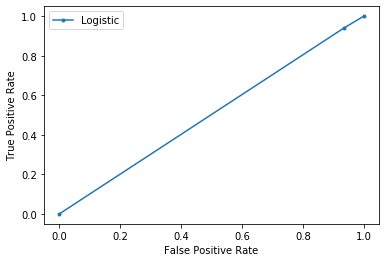

In [47]:
##########################################################################################
##### Understanding AUC - ROC Curve

from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
from matplotlib import pyplot
# calculate scores

lr_auc = roc_auc_score(y_test, y_pred3)
# summarize scores

print('Logistic: ROC AUC=%.3f' % (lr_auc))
# calculate roc curves


lr_fpr, lr_tpr, thresholds = roc_curve(y_test,  y_pred3)
# plot the roc curve for the model

pyplot.plot(lr_fpr, lr_tpr, marker='.', label='Logistic')
# axis labels
pyplot.xlabel('False Positive Rate')
pyplot.ylabel('True Positive Rate')
# show the legend
pyplot.legend()
# show the plot
pyplot.show()

# Use Lag1 and Lag2 as predictiors

In [48]:
X = m3[['Lag1', 'Lag2']].values
y = m3['Direction_Up'].values.reshape(-1,1)

#Prior to training our model, we’ll set aside a portion of our data in order to evaluate its performance.

x_train, x_test, y_train, y_test = train_test_split(X, y, random_state=1)
X.shape

lr = LogisticRegression()
lr.fit(x_train, y_train)

print(lr.coef_)
print(lr.intercept_)

## Let’s see how the model performs against data that it hasn’t been trained on, that is test data.
## Sci-Kit learn is using a threshold of P>0.5 for binary classifications
y_pred = lr.predict(x_test)
y_pred.mean()
y_pred[:5]



[[-0.03921288 -0.02765762]]
[0.10494945]


C:\Users\rashraf\AppData\Local\Continuum\anaconda3\lib\site-packages\sklearn\utils\validation.py:72: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  return f(**kwargs)


array([1, 1, 1, 1, 1], dtype=uint8)

In [49]:
confusion_matrix(y_test, y_pred3) 

array([[ 10, 148],
       [  9, 146]], dtype=int64)

In [50]:
accuracy = np.mean(y_pred3 == y_test)
print ('accuracy = {0}%'.format(accuracy*100)  )

accuracy = 49.84025559105431%


# Comparison of Model Accuracy 
Model accuracy did not improve when only Lag1 and Lag2 returns are used to predict market movememt.

The model is no better than random guess!
It is difficult to predict future performance using past market performance